# Scenario Design

This notebook develops macroeconomic scenarios for the stress-testing. The purpose of this stage is to connect the previously estimated regression model with those assumptions.

The methodogy is based on the NBU (National Bank of Ukraine) stress-testing approach (“Стрес-тестування банків у 2025 році та якість кредитів”, НБУ, 2025).

The NBU proposes 2 scenarios:
1) `baseline`: real NBU's forecast.
2) `adverse`: deep and prolonged crisis which is possible but unlikely.  

The NBU provides official predictions for those scenarios (except for `policy_rate`). 

However, in both NBU-based scenarios, the projected NPL ratio decreases (as it is shown later here). Therefore, an additional `severe adverse` scenario is added. This scenario is more severe and stressful.

**Notes**:
- The last year of available historical data is 2024, so assumptions are applied to 2025.

- The NBU assumptions are annual, but the model uses quarterly data. Therefore, the annual assumptions are evenly divided across the four quarters of 2025.

The output of this notebook is a projected NPL path under different scenarios. These results are later used as an input for the Monte Carlo simulation stage.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# final regression coefficients

beta_const = -3.2663
beta_gdp = -8.0813
beta_policy = 0.1449
beta_fx = 8.2056

### Scenario assumptions for 2025 

In [11]:
scenario_annual = pd.DataFrame({
    "scenario": ["baseline", "adverse", "severe adverse"],
    "gdp_growth_percent": [3.1, -3.1, -5],
    "CPI_percent": [8.7, 17.9, 22], # but we don't use it in regression -> delete or add to regression
    "fx_change_percent": [5.9, 11.2, 18],
    "policy_rate": [14, 16, 20.0]  
})

scenario_annual

,scenario,gdp_growth_percent,CPI_percent,fx_change_percent,policy_rate
0,baseline,3.1,8.7,5.9,14.0
1,adverse,-3.1,17.9,11.2,16.0
2,severe adverse,-5.0,22.0,18.0,20.0


In [12]:
quarters = pd.period_range("2025Q1", "2025Q4", freq="Q")

scenario_quarterly = []

for _, row in scenario_annual.iterrows():
    for q in quarters:
        scenario_quarterly.append({
            "quarter": q,
            "scenario": row["scenario"],
            "gdp_growth_percent": row["gdp_growth_percent"],
            "CPI_percent": row["CPI_percent"],
            "fx_change_percent": row["fx_change_percent"],
            "policy_rate": row["policy_rate"]
        })

scenario_quarterly = pd.DataFrame(scenario_quarterly)

scenario_quarterly

,quarter,scenario,gdp_growth_percent,CPI_percent,fx_change_percent,policy_rate
0,2025Q1,baseline,3.1,8.7,5.9,14.0
1,2025Q2,baseline,3.1,8.7,5.9,14.0
2,2025Q3,baseline,3.1,8.7,5.9,14.0
3,2025Q4,baseline,3.1,8.7,5.9,14.0
4,2025Q1,adverse,-3.1,17.9,11.2,16.0
5,2025Q2,adverse,-3.1,17.9,11.2,16.0
6,2025Q3,adverse,-3.1,17.9,11.2,16.0
7,2025Q4,adverse,-3.1,17.9,11.2,16.0
8,2025Q1,severe adverse,-5.0,22.0,18.0,20.0
9,2025Q2,severe adverse,-5.0,22.0,18.0,20.0


For consistency with the regression model:
- `gdp growth` is converted from percent to decimal form. 
- `exchange rate` change is converted into log-change. 
- `policy rate` is kept in percentage points.

In [19]:
scenario_quarterly["gdp_growth"] = scenario_quarterly["gdp_growth_percent"] / 100

scenario_quarterly["fx_change"] = (
    np.log(1 + scenario_quarterly["fx_change_percent"] / 100) / 4
)

scenario_quarterly[[
    "quarter", 
    "scenario", 
    "gdp_growth", 
    "policy_rate", 
    "fx_change", 
    "CPI_percent"
]]

,quarter,scenario,gdp_growth,policy_rate,fx_change,CPI_percent
0,2025Q1,baseline,0.031,14.0,0.014331,8.7
1,2025Q2,baseline,0.031,14.0,0.014331,8.7
2,2025Q3,baseline,0.031,14.0,0.014331,8.7
3,2025Q4,baseline,0.031,14.0,0.014331,8.7
4,2025Q1,adverse,-0.031,16.0,0.026540,17.9
5,2025Q2,adverse,-0.031,16.0,0.026540,17.9
6,2025Q3,adverse,-0.031,16.0,0.026540,17.9
7,2025Q4,adverse,-0.031,16.0,0.026540,17.9
8,2025Q1,severe adverse,-0.050,20.0,0.041379,22.0
9,2025Q2,severe adverse,-0.050,20.0,0.041379,22.0


### Apply the regression model to scenario assumptions

In [14]:
scenario_quarterly["predicted_d_NPL"] = (
    beta_const
    + beta_gdp * scenario_quarterly["gdp_growth"]
    + beta_policy * scenario_quarterly["policy_rate"]
    + beta_fx * scenario_quarterly["fx_change"]
)

scenario_quarterly[[
    "quarter",
    "scenario",
    "gdp_growth",
    "policy_rate",
    "fx_change",
    "predicted_d_NPL"
]]

,quarter,scenario,gdp_growth,policy_rate,fx_change,predicted_d_NPL
0,2025Q1,baseline,0.031,14.0,0.014331,-1.370624
1,2025Q2,baseline,0.031,14.0,0.014331,-1.370624
2,2025Q3,baseline,0.031,14.0,0.014331,-1.370624
3,2025Q4,baseline,0.031,14.0,0.014331,-1.370624
4,2025Q1,adverse,-0.031,16.0,0.026540,-0.479603
5,2025Q2,adverse,-0.031,16.0,0.026540,-0.479603
6,2025Q3,adverse,-0.031,16.0,0.026540,-0.479603
7,2025Q4,adverse,-0.031,16.0,0.026540,-0.479603
8,2025Q1,severe adverse,-0.050,20.0,0.041379,0.375301
9,2025Q2,severe adverse,-0.050,20.0,0.041379,0.375301


In [15]:
df = pd.read_excel("../../data_processed/quarterly_data.xlsx")

df["date"] = pd.PeriodIndex(df["date"], freq="Q")

last_actual_quarter = df["date"].max()
last_actual_npl = df.loc[df["date"] == last_actual_quarter, "NPL"].iloc[0]

print("Last actual quarter:", last_actual_quarter)
print("Last actual NPL:", last_actual_npl)

Last actual quarter: 2024Q4
Last actual NPL: 30.2882706427491


### Build projected NPL paths

In [16]:
projected_paths = []

for scenario_name, group in scenario_quarterly.groupby("scenario"):
    group = group.sort_values("quarter").copy()
    
    npl_values = []
    current_npl = last_actual_npl
    
    for _, row in group.iterrows():
        current_npl = current_npl + row["predicted_d_NPL"]
        npl_values.append(current_npl)
    
    group["projected_NPL"] = npl_values
    projected_paths.append(group)

scenario_projection = pd.concat(projected_paths, ignore_index=True)

scenario_projection[[
    "quarter",
    "scenario",
    "predicted_d_NPL",
    "projected_NPL"
]]

,quarter,scenario,predicted_d_NPL,projected_NPL
0,2025Q1,adverse,-0.479603,29.808668
1,2025Q2,adverse,-0.479603,29.329065
2,2025Q3,adverse,-0.479603,28.849463
3,2025Q4,adverse,-0.479603,28.369860
4,2025Q1,baseline,-1.370624,28.917647
5,2025Q2,baseline,-1.370624,27.547023
6,2025Q3,baseline,-1.370624,26.176400
7,2025Q4,baseline,-1.370624,24.805776
8,2025Q1,severe adverse,0.375301,30.663572
9,2025Q2,severe adverse,0.375301,31.038873


The scenario results show that the projected NPL ratio declines under both NBU-based scenarios: **baseline, adverse**. However, under the **adverse** scenario, the NPL ratio declines only slightly. This suggests that there is a *downward tendency* in NPL ratio observed in the historical data and that those stated assumptions are not strong enough to fully offset it.

Under the **severe adverse** scenario, NPL ratio increases, which makes this scenario actually *stressful :)* and more suitable for stress-testing purposes.

### Visualize projected NPL paths

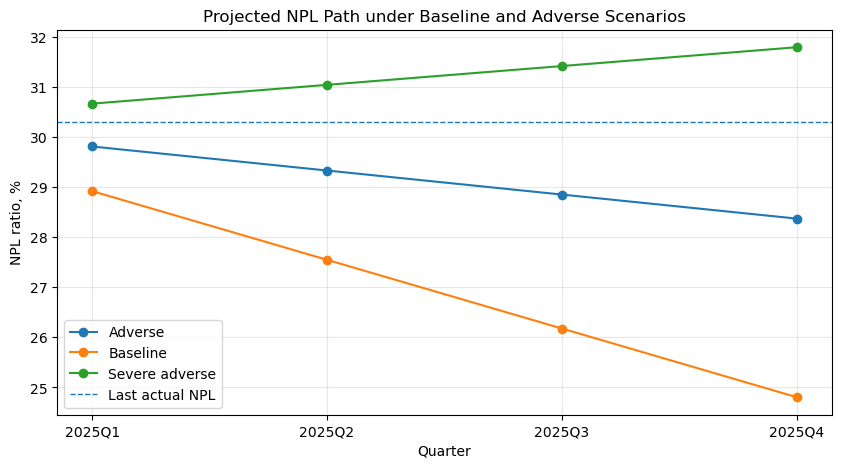

In [17]:
plt.figure(figsize=(10, 5))

for scenario_name, group in scenario_projection.groupby("scenario"):
    plt.plot(
        group["quarter"].astype(str),
        group["projected_NPL"],
        marker="o",
        label=scenario_name.capitalize()
    )

plt.axhline(
    y=last_actual_npl,
    linestyle="--",
    linewidth=1,
    label="Last actual NPL"
)

plt.title("Projected NPL Path under Baseline and Adverse Scenarios")
plt.xlabel("Quarter")
plt.ylabel("NPL ratio, %")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
final_comparison = scenario_projection.groupby("scenario").agg(
    final_projected_NPL=("projected_NPL", "last"),
    average_predicted_d_NPL=("predicted_d_NPL", "mean"),
    cumulative_d_NPL=("predicted_d_NPL", "sum")
).reset_index()

final_comparison

,scenario,final_projected_NPL,average_predicted_d_NPL,cumulative_d_NPL
0,adverse,28.369860,-0.479603,-1.918411
1,baseline,24.805776,-1.370624,-5.482495
2,severe adverse,31.789476,0.375301,1.501205


Для мене:
1) CPI - добавить до регресії або видалить 
2) Чи точно приріст ВВП в прогнозах НБУ це такий самий приріст як у мене в датасеті
3) Чи точно ок, що при обох сценаріях від НБУ NPL падає